## Expert policy validation

Test the rule-based expert policy ('src/highway_bc/expert_policy.py')
across 15 different random seeds to check if there are any crashes or problems.

In [ ]:
# adds /src to paths where the search for imports happens
import sys; sys.path.append("../src")

In [5]:
from highway_bc.expert_policy import expert_policy
import gymnasium
import highway_env

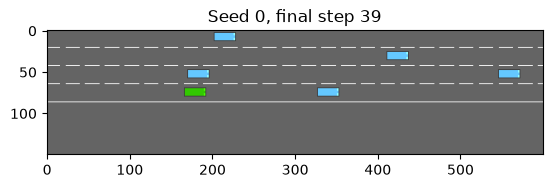

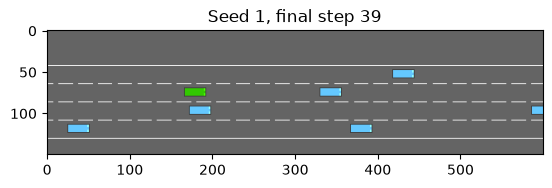

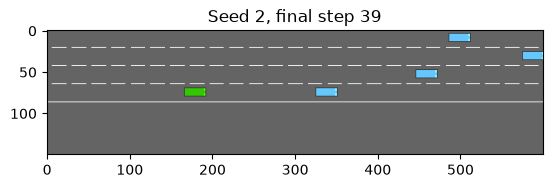

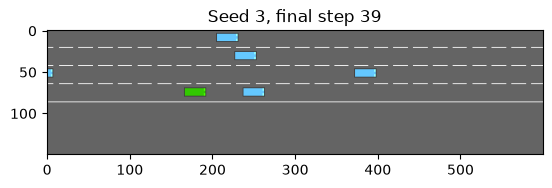

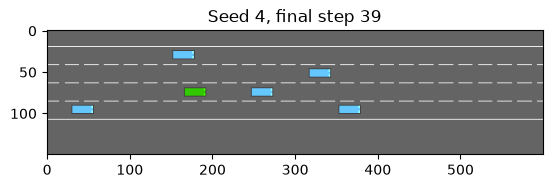

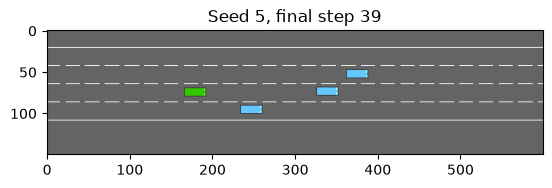

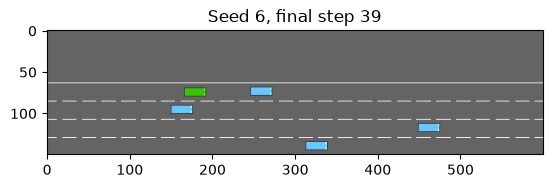

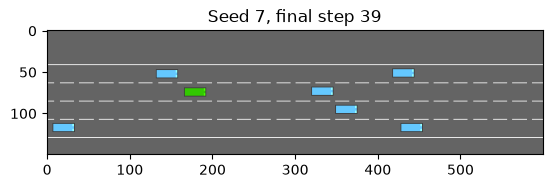

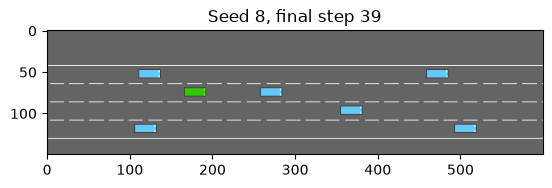

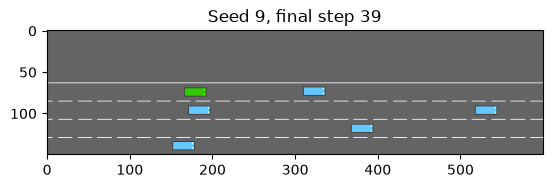

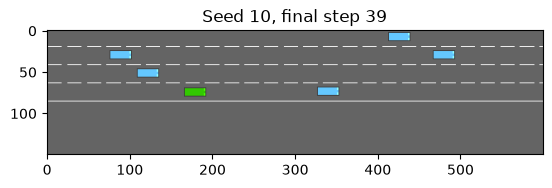

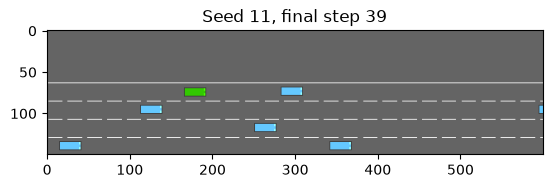

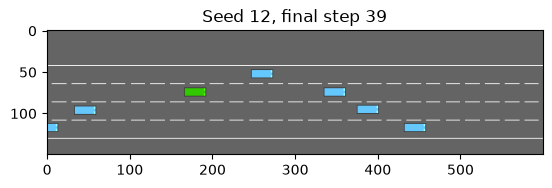

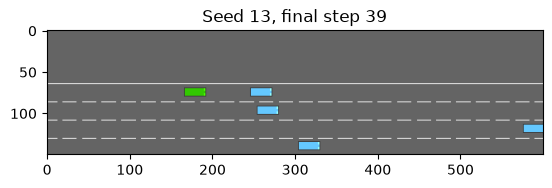

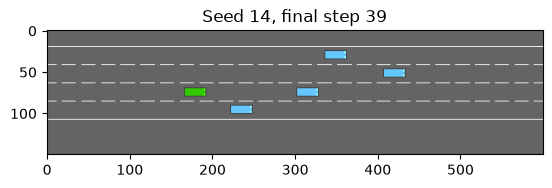

In [6]:
from matplotlib import pyplot as plt
%matplotlib inline

env = gymnasium.make('highway-v0', render_mode='rgb_array')
action_indexes = env.unwrapped.action_type.actions_indexes

for seed in range(15):
    obs, info = env.reset(seed=seed)
    for step in range(50):
        available_actions = env.unwrapped.action_type.get_available_actions()
        action = expert_policy(obs, action_indexes, available_actions)
        obs, reward, done, truncated, info = env.step(action)
        if done or truncated:
            break

    plt.imshow(env.render())
    plt.title(f"Seed {seed}, final step {step}")
    plt.show()